In [19]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [20]:
# 1. Load Gambar Asli
img_raw = Image.open('Surdik.JPG').convert('L') # Ubah ke Grayscale

# 2. Resize Gambar
basewidth = 800
w_percent = (basewidth / float(img_raw.size[0]))
h_size = int((float(img_raw.size[1]) * float(w_percent)))
img_resized = img_raw.resize((basewidth, h_size), Image.Resampling.LANCZOS)

# Ubah ke array numpy untuk perhitungan matematika
img_array = np.array(img_resized, dtype=np.float64)
print(f"Gambar siap diproses dengan ukuran: {img_array.shape[1]}x{img_array.shape[0]}")

Gambar siap diproses dengan ukuran: 800x533


In [21]:
# Membuat matriks 5x5 berisi angka 1
kernel_size = 5
kernel_ones = np.ones((kernel_size, kernel_size))

# Normalisasi dengan membagi jumlah elemen (5x5 = 25)
kernel_rataan = kernel_ones / (kernel_size * kernel_size)

print("Kernel Rataan 5x5:\n", kernel_rataan)

Kernel Rataan 5x5:
 [[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


In [22]:
# Hitung lebar padding (untuk kernel 5x5, padding adalah 2 pixel)
pad_size = kernel_size // 2

# Menambahkan bingkai nol (zero padding) di sekeliling gambar
img_padded = np.pad(img_array, ((pad_size, pad_size), (pad_size, pad_size)), mode='constant')

print(f"Ukuran gambar setelah padding: {img_padded.shape[1]}x{img_padded.shape[0]}")

Ukuran gambar setelah padding: 804x537


In [23]:
# Siapkan wadah kosong untuk hasil konvolusi
img_h, img_w = img_array.shape
output_array = np.zeros((img_h, img_w))

# Iterasi setiap pixel gambar
for i in range(img_h):
    for j in range(img_w):
        # Ambil area 5x5 dari gambar yang sudah dipadding
        # Koordinat disesuaikan dengan posisi pixel (i, j)
        region = img_padded[i:i+kernel_size, j:j+kernel_size]

        # Hitung nilai rata-rata (Konvolusi)
        # Kalikan elemen-per-elemen lalu jumlahkan
        output_array[i, j] = np.sum(region * kernel_rataan)

# Konversi kembali ke format standar gambar (0-255)
output_final = np.clip(output_array, 0, 255).astype(np.uint8)
print("Proses konvolusi manual selesai.")

Proses konvolusi manual selesai.


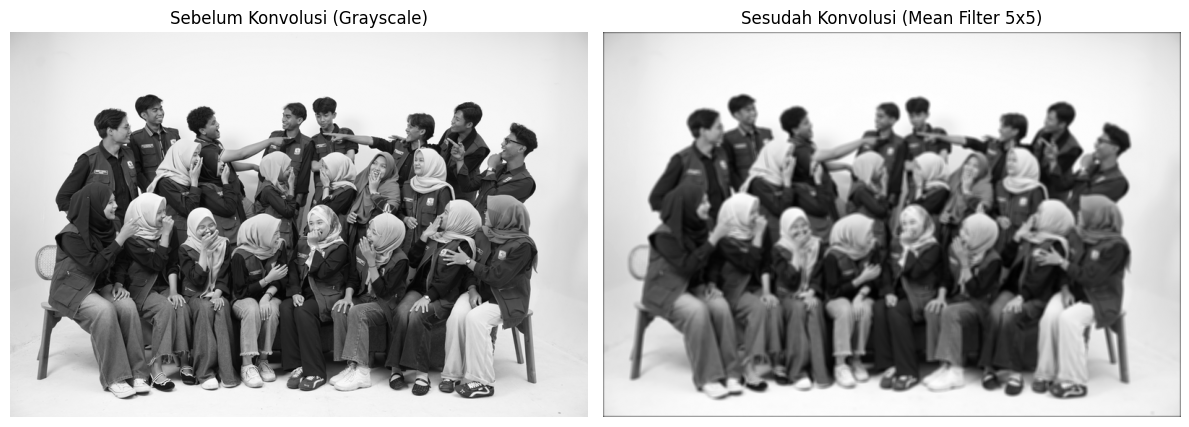

In [25]:
# Tampilkan Perbandingan
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Sebelum Konvolusi (Grayscale)")
plt.imshow(img_array, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Sesudah Konvolusi (Mean Filter 5x5)")
plt.imshow(output_final, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()